In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/house-prices-advanced-regression-techniques/sample_submission.csv
/kaggle/input/house-prices-advanced-regression-techniques/data_description.txt
/kaggle/input/house-prices-advanced-regression-techniques/train.csv
/kaggle/input/house-prices-advanced-regression-techniques/test.csv


In [2]:
df = pd.read_csv("/kaggle/input/house-prices-advanced-regression-techniques/train.csv")


In [3]:
df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

In [5]:
df.describe()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


In [6]:
missing = pd.DataFrame({
    "dtype": df.dtypes,
    "missing_count": df.isna().sum(),
    "missing_pct": df.isna().mean() * 100  # % пропусков
})

missing = missing[missing["missing_count"] > 0]
missing.sort_values(by="missing_count", ascending=False)

,dtype,missing_count,missing_pct
PoolQC,object,1453,99.520548
MiscFeature,object,1406,96.301370
Alley,object,1369,93.767123
Fence,object,1179,80.753425
MasVnrType,object,872,59.726027
FireplaceQu,object,690,47.260274
LotFrontage,float64,259,17.739726
GarageType,object,81,5.547945
GarageYrBlt,float64,81,5.547945
GarageFinish,object,81,5.547945


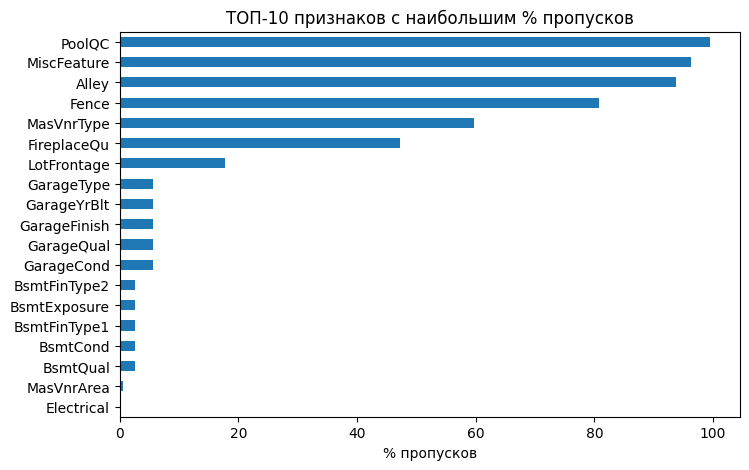

In [7]:
import matplotlib.pyplot as plt

missing.sort_values("missing_pct").plot(
    kind="barh", y="missing_pct", legend=False, figsize=(8,5)
)
plt.title("ТОП-10 признаков с наибольшим % пропусков")
plt.xlabel("% пропусков")
plt.show()

In [8]:
df = df.drop(columns=["PoolQC", "Alley", "MiscFeature", "Fence"])

In [9]:
missing.sort_values(by="missing_count", ascending=False)

,dtype,missing_count,missing_pct
PoolQC,object,1453,99.520548
MiscFeature,object,1406,96.301370
Alley,object,1369,93.767123
Fence,object,1179,80.753425
MasVnrType,object,872,59.726027
FireplaceQu,object,690,47.260274
LotFrontage,float64,259,17.739726
GarageType,object,81,5.547945
GarageYrBlt,float64,81,5.547945
GarageFinish,object,81,5.547945


Обработка признаков с типом object

In [10]:
cols_none = [
    "MasVnrType", "FireplaceQu", "GarageType", 
    "GarageFinish", "GarageQual", "GarageCond",
    "BsmtExposure", "BsmtQual", "BsmtCond", 
    "BsmtFinType1", "BsmtFinType2"
]

df[cols_none] = df[cols_none].fillna("None")
df["Electrical"] = df["Electrical"].fillna(df["Electrical"].mode()[0])


In [11]:
df["LotFrontage"] = df["LotFrontage"].fillna(df["LotFrontage"].median())
df.loc[df["MasVnrType"] == "None", "MasVnrArea"] = 0
df["MasVnrArea"] = df["MasVnrArea"].fillna(df["MasVnrArea"].median())
df.loc[df["GarageType"] == "None", "GarageYrBlt"] = 0
df["GarageYrBlt"] = df["GarageYrBlt"].fillna(df["GarageYrBlt"].median())

In [12]:
df.isna().sum()[df.isna().sum() > 0]

Series([], dtype: int64)

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


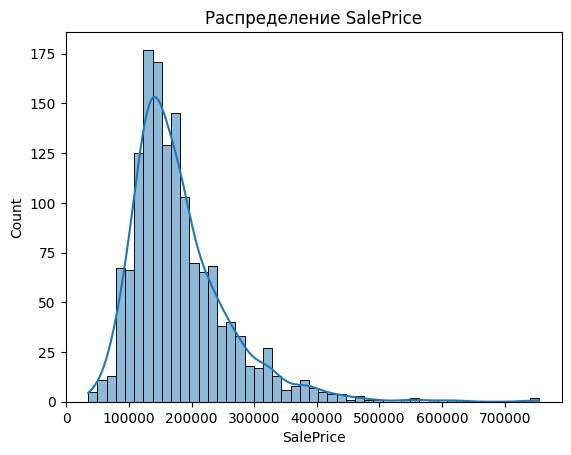

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.histplot(df["SalePrice"], kde=True)
plt.title("Распределение SalePrice")
plt.show()

Из-за того что наше распределение имеет длинный правый хвост, то мы приводим его к нормальному распределению с помощью логорифмирования целевой переменной

In [14]:
import numpy as np
df["SalePrice_log"] = np.log1p(df["SalePrice"])

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


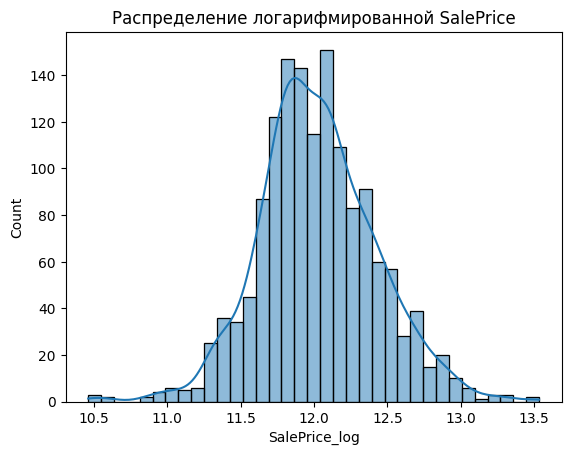

In [15]:
sns.histplot(df["SalePrice_log"], kde=True)
plt.title("Распределение логарифмированной SalePrice")
plt.show()

In [16]:
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns

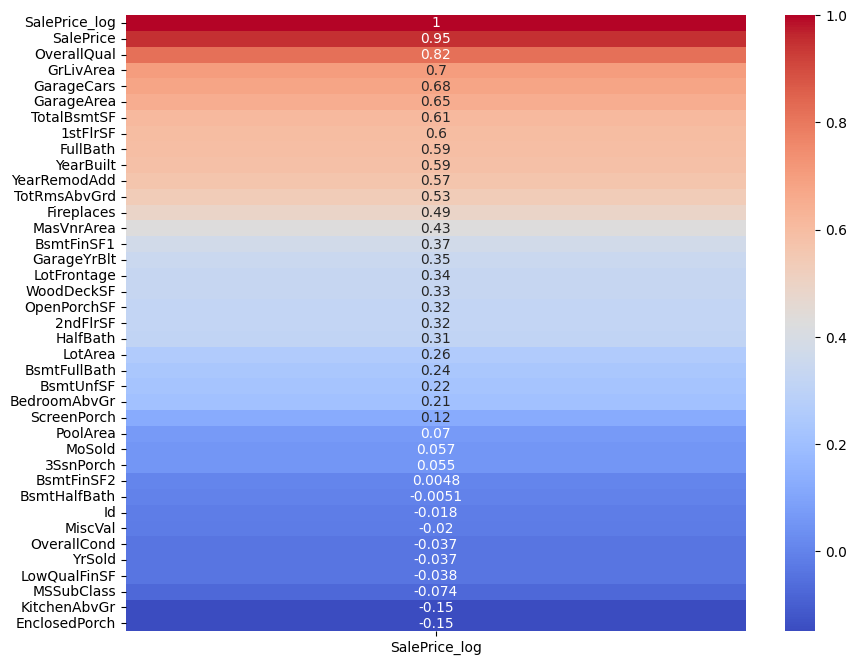

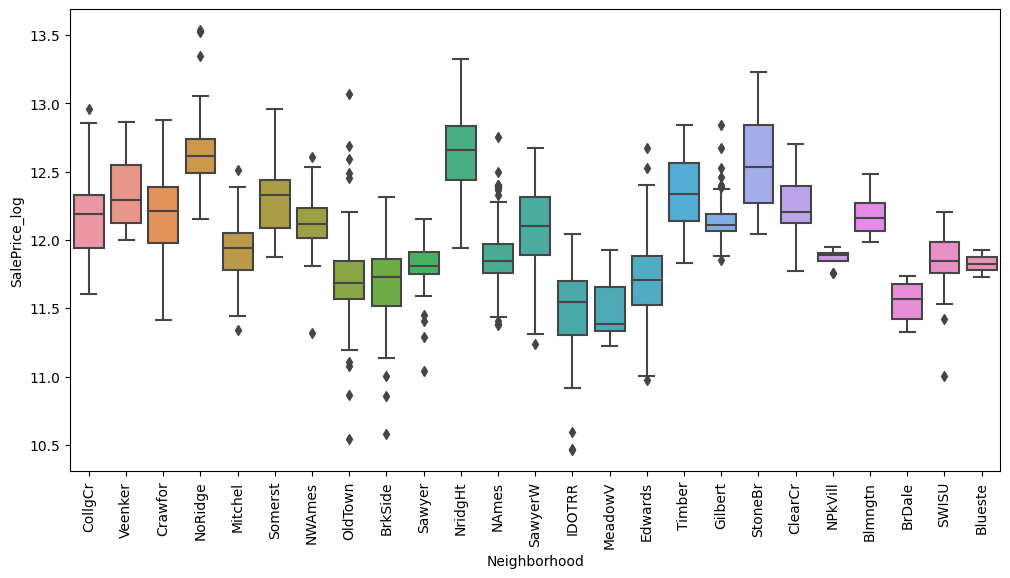

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt

# Корреляция числовых признаков с ценой (heatmap)
plt.figure(figsize=(10,8))
sns.heatmap(df[numeric_cols].corr()[["SalePrice_log"]].sort_values(by="SalePrice_log", ascending=False),
            annot=True, cmap="coolwarm")
plt.show()

# Boxplot для категориальных признаков
plt.figure(figsize=(12,6))
sns.boxplot(x="Neighborhood", y="SalePrice_log", data=df)
plt.xticks(rotation=90)
plt.show()

In [18]:
# Берём только числовые признаки
numeric_df = df.select_dtypes(include=["number"])

# Вычисляем корреляцию
corr = numeric_df.corr()

# Порог корреляции
threshold = 0.5

# Находим признаки с корреляцией ниже порога
features_to_drop = corr.index[abs(corr["SalePrice_log"]) < threshold].tolist()

# Удаляем их
df.drop(columns=features_to_drop, inplace=True)

print(f"Удалено признаков: {len(features_to_drop)}")
print(f"Новое количество столбцов: {df.shape[1]}")

Удалено признаков: 27
Новое количество столбцов: 51


In [19]:
categorical_cols = df.select_dtypes(include=["object"]).columns
for col in categorical_cols:
    print(col, df[col].nunique())

MSZoning 5
Street 2
LotShape 4
LandContour 4
Utilities 2
LotConfig 5
LandSlope 3
Neighborhood 25
Condition1 9
Condition2 8
BldgType 5
HouseStyle 8
RoofStyle 6
RoofMatl 8
Exterior1st 15
Exterior2nd 16
MasVnrType 4
ExterQual 4
ExterCond 5
Foundation 6
BsmtQual 5
BsmtCond 5
BsmtExposure 5
BsmtFinType1 7
BsmtFinType2 7
Heating 6
HeatingQC 5
CentralAir 2
Electrical 5
KitchenQual 4
Functional 7
FireplaceQu 6
GarageType 7
GarageFinish 4
GarageQual 6
GarageCond 6
PavedDrive 3
SaleType 9
SaleCondition 6


In [20]:
cat_cols = df.select_dtypes(include=["object"]).columns
high_cardinality = [col for col in cat_cols if df[col].nunique() > 5]
df.drop(columns=high_cardinality, inplace=True)

In [21]:
print(f"Новое количество столбцов: {df.shape[1]}")

Новое количество столбцов: 32


In [22]:
categorical_cols = df.select_dtypes(include=["object"]).columns
for col in categorical_cols:
    print(col, df[col].nunique())

MSZoning 5
Street 2
LotShape 4
LandContour 4
Utilities 2
LotConfig 5
LandSlope 3
BldgType 5
MasVnrType 4
ExterQual 4
ExterCond 5
BsmtQual 5
BsmtCond 5
BsmtExposure 5
HeatingQC 5
CentralAir 2
Electrical 5
KitchenQual 4
GarageFinish 4
PavedDrive 3


In [23]:
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns

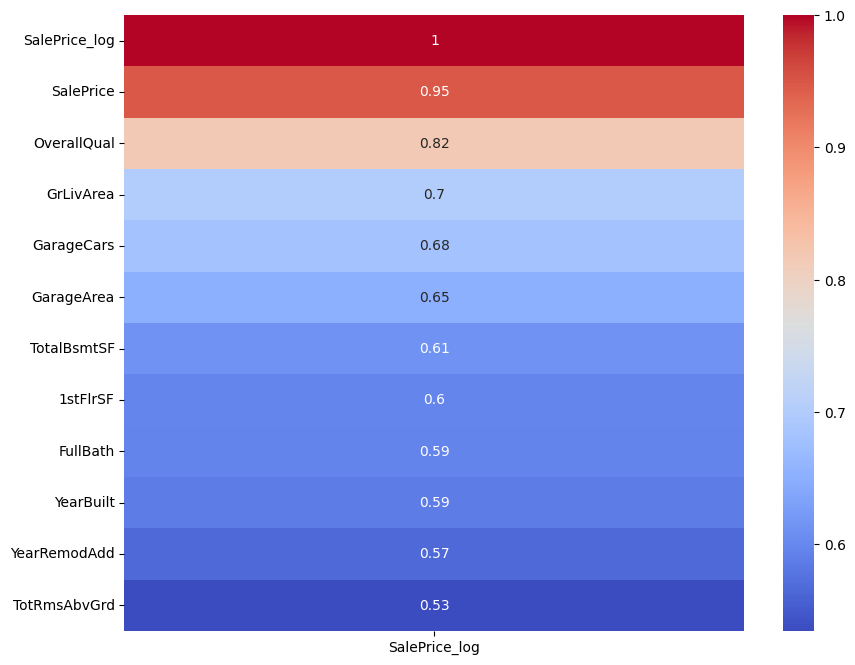

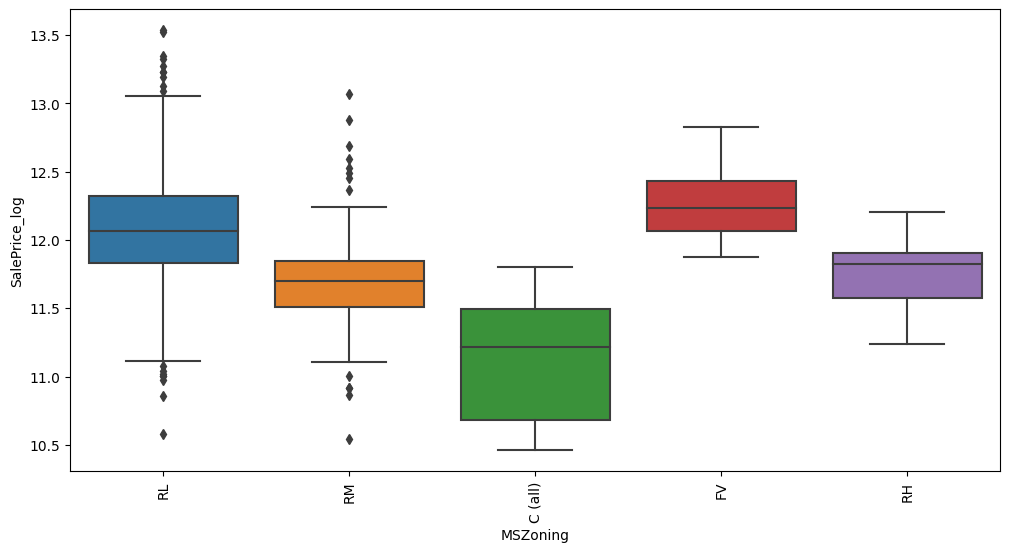

In [24]:
# Корреляция числовых признаков с ценой (heatmap)
plt.figure(figsize=(10,8))
sns.heatmap(df[numeric_cols].corr()[["SalePrice_log"]].sort_values(by="SalePrice_log", ascending=False),
            annot=True, cmap="coolwarm")
plt.show()

# Boxplot для категориальных признаков
plt.figure(figsize=(12,6))
sns.boxplot(x="MSZoning", y="SalePrice_log", data=df)
plt.xticks(rotation=90)
plt.show()

In [25]:
print(df.columns)

Index(['MSZoning', 'Street', 'LotShape', 'LandContour', 'Utilities',
       'LotConfig', 'LandSlope', 'BldgType', 'OverallQual', 'YearBuilt',
       'YearRemodAdd', 'MasVnrType', 'ExterQual', 'ExterCond', 'BsmtQual',
       'BsmtCond', 'BsmtExposure', 'TotalBsmtSF', 'HeatingQC', 'CentralAir',
       'Electrical', '1stFlrSF', 'GrLivArea', 'FullBath', 'KitchenQual',
       'TotRmsAbvGrd', 'GarageFinish', 'GarageCars', 'GarageArea',
       'PavedDrive', 'SalePrice', 'SalePrice_log'],
      dtype='object')


In [26]:
print(f"Новое количество столбцов: {df.shape[1]}")

Новое количество столбцов: 32


In [27]:
categorical_cols = df.select_dtypes(include=['object']).columns
print("Категориальные признаки:", list(categorical_cols))

Категориальные признаки: ['MSZoning', 'Street', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'BldgType', 'MasVnrType', 'ExterQual', 'ExterCond', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'HeatingQC', 'CentralAir', 'Electrical', 'KitchenQual', 'GarageFinish', 'PavedDrive']


In [28]:
unique_counts = df[categorical_cols].nunique().sort_values()
print(unique_counts)

Street          2
CentralAir      2
Utilities       2
PavedDrive      3
LandSlope       3
KitchenQual     4
GarageFinish    4
MasVnrType      4
ExterQual       4
LandContour     4
LotShape        4
LotConfig       5
ExterCond       5
BsmtQual        5
BsmtCond        5
BsmtExposure    5
HeatingQC       5
Electrical      5
BldgType        5
MSZoning        5
dtype: int64


In [29]:
one_hot_cols = unique_counts[unique_counts <= 5].index.tolist()

print("One-hot encoding:", one_hot_cols)

One-hot encoding: ['Street', 'CentralAir', 'Utilities', 'PavedDrive', 'LandSlope', 'KitchenQual', 'GarageFinish', 'MasVnrType', 'ExterQual', 'LandContour', 'LotShape', 'LotConfig', 'ExterCond', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'HeatingQC', 'Electrical', 'BldgType', 'MSZoning']


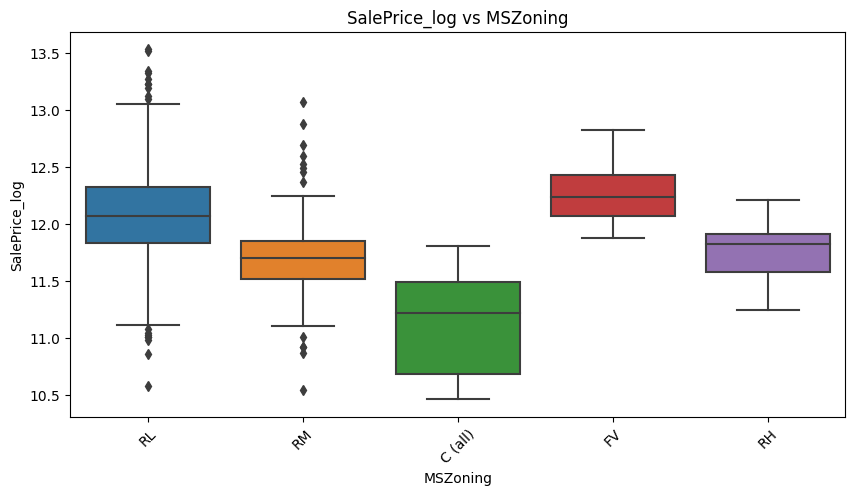

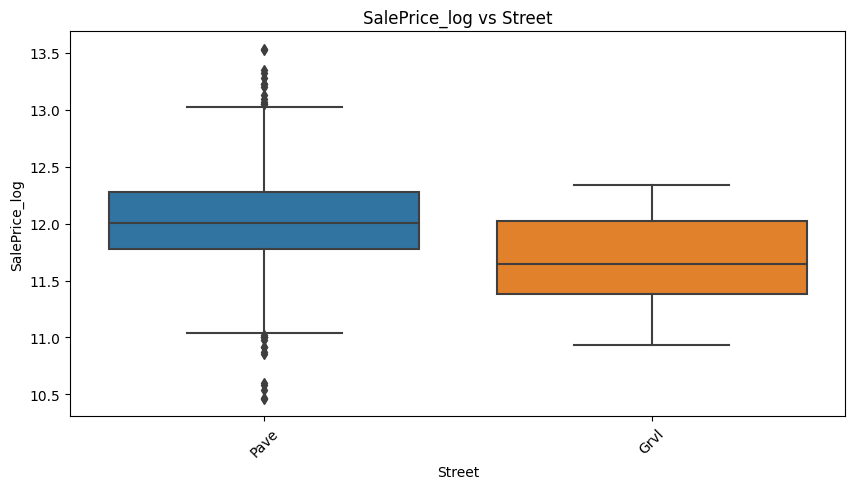

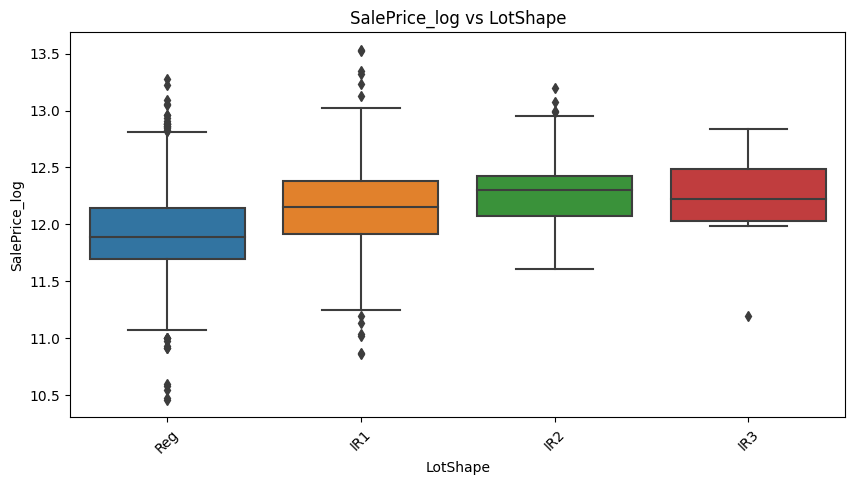

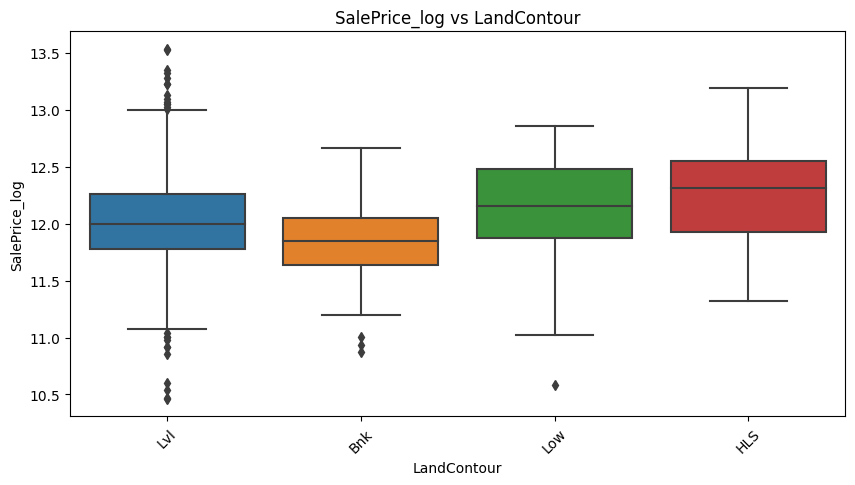

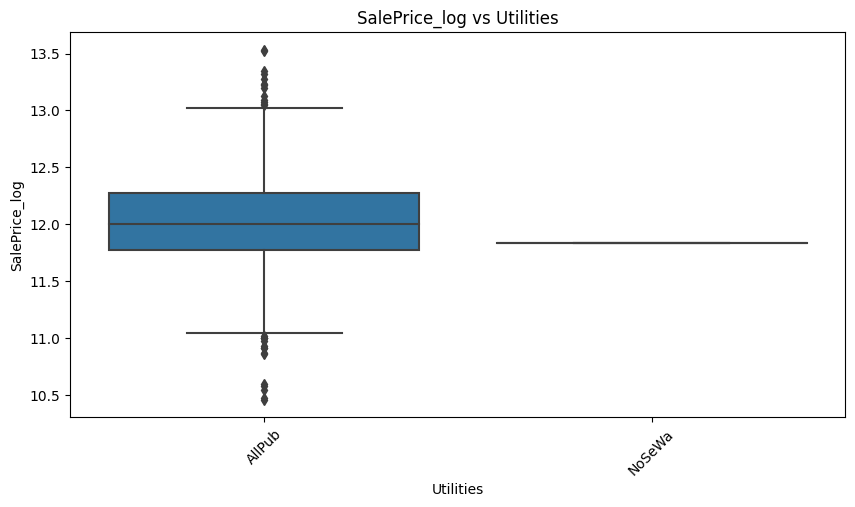

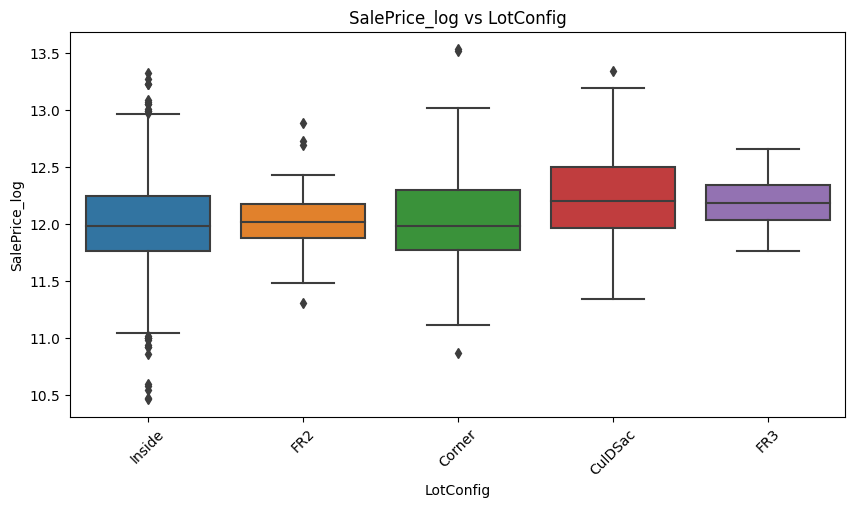

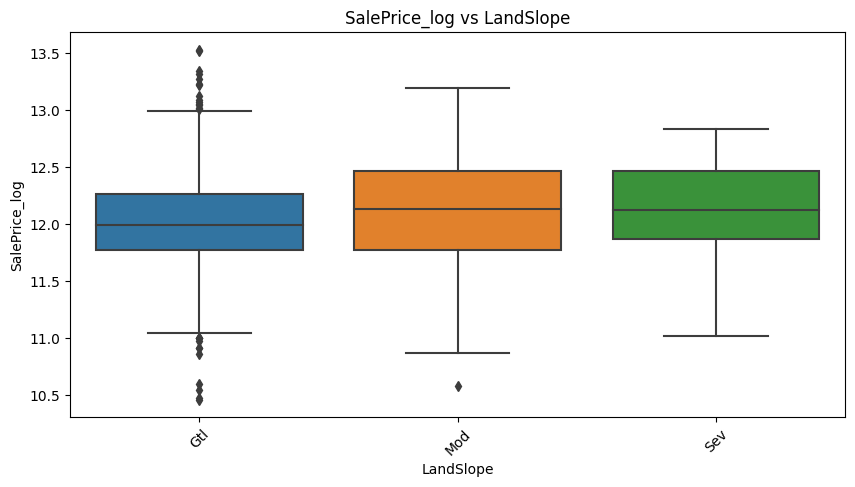

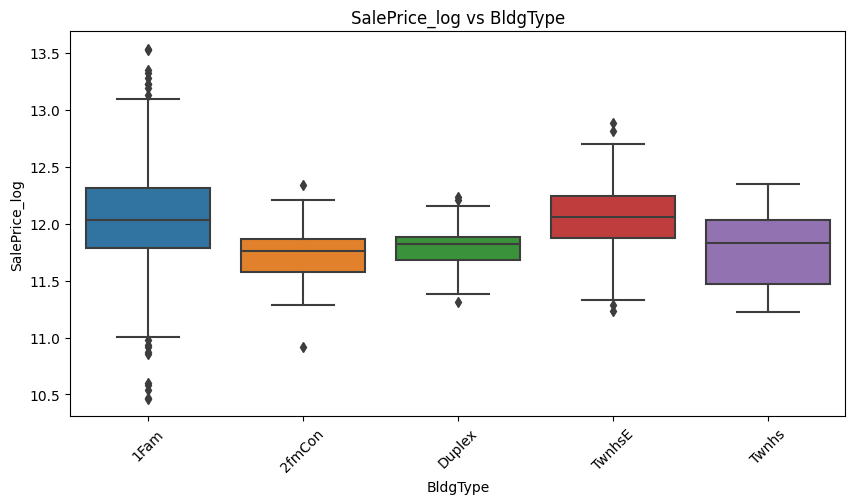

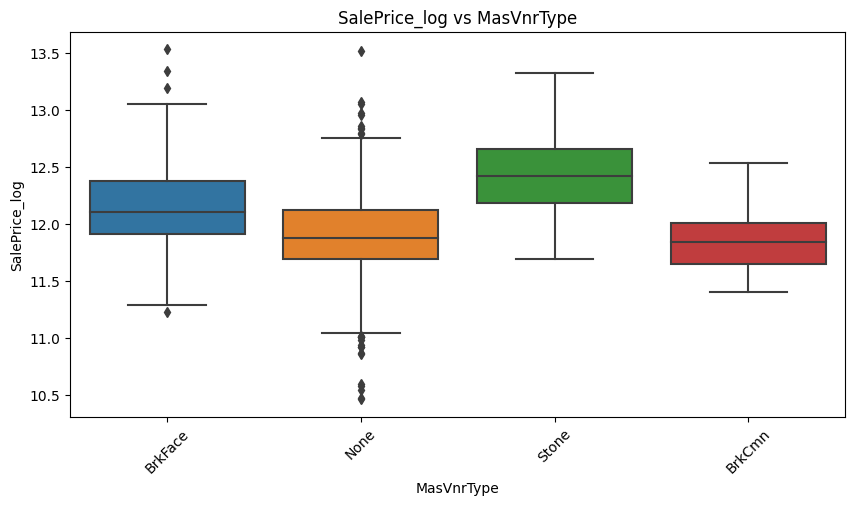

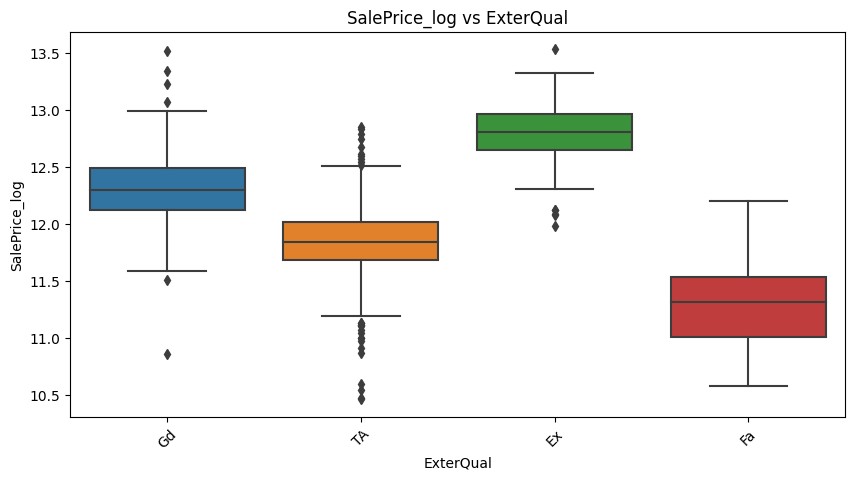

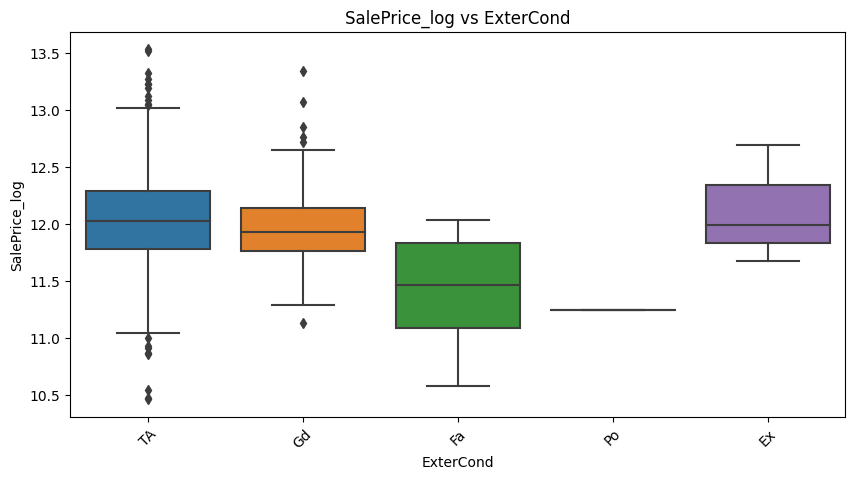

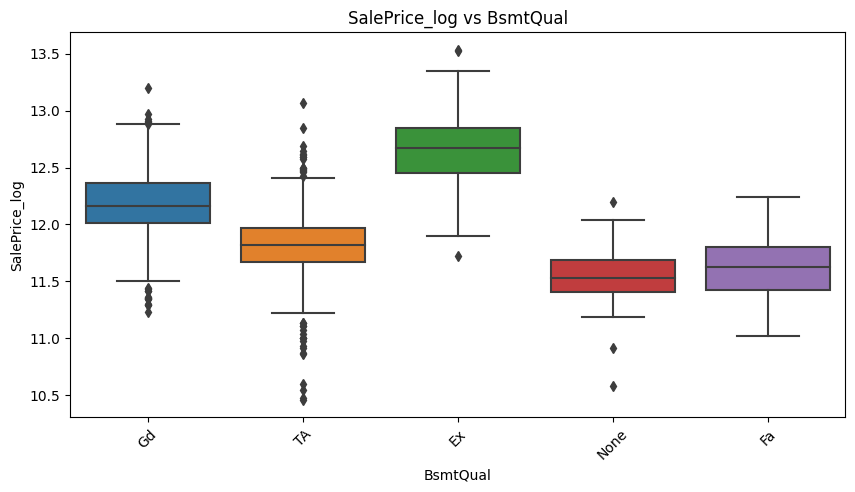

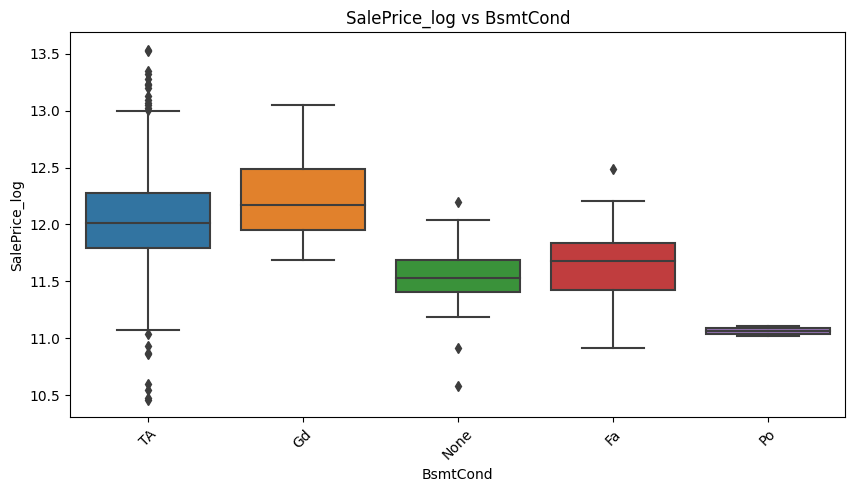

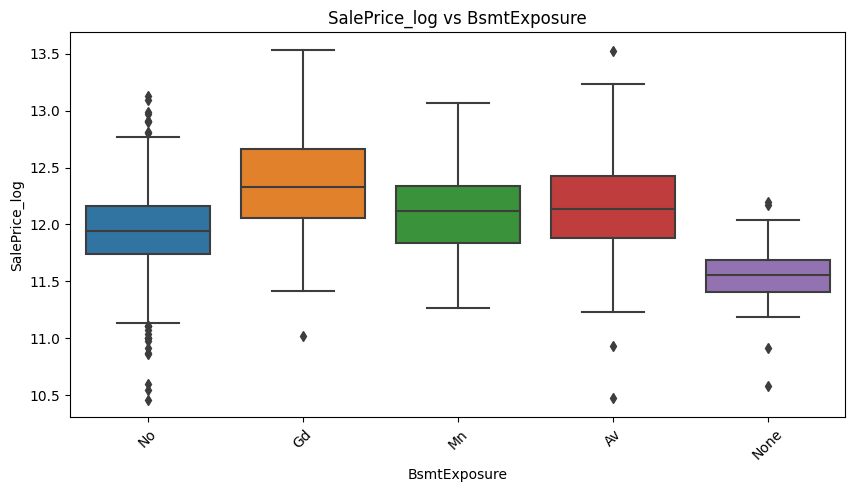

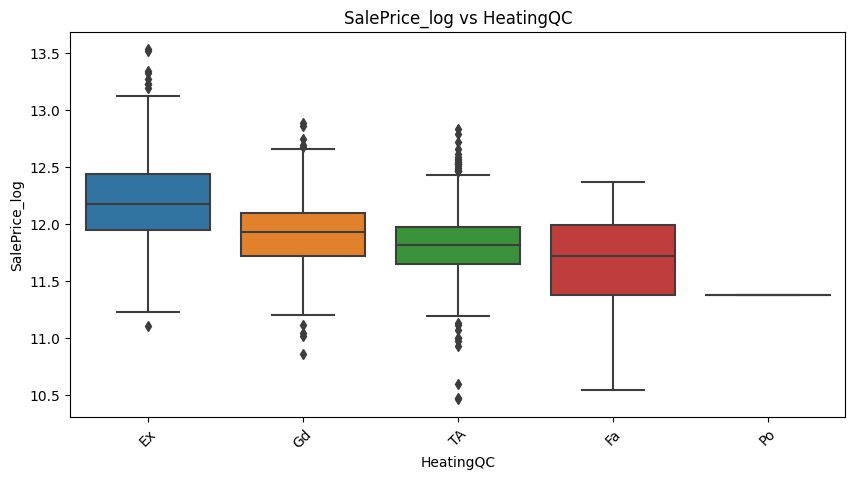

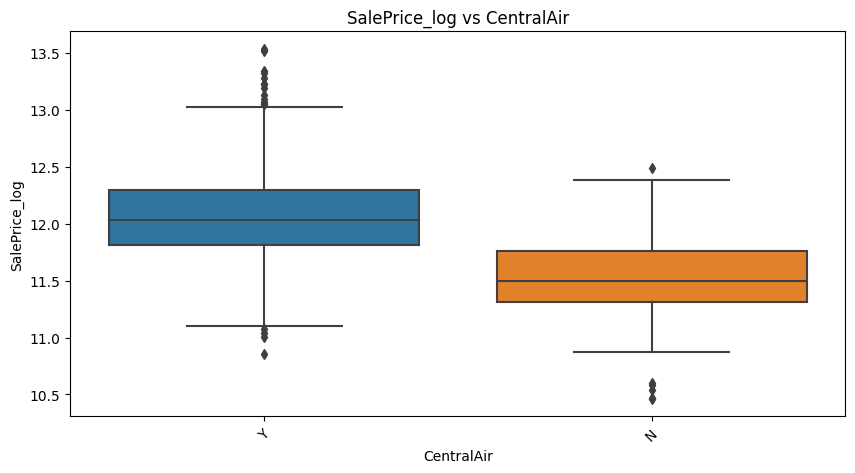

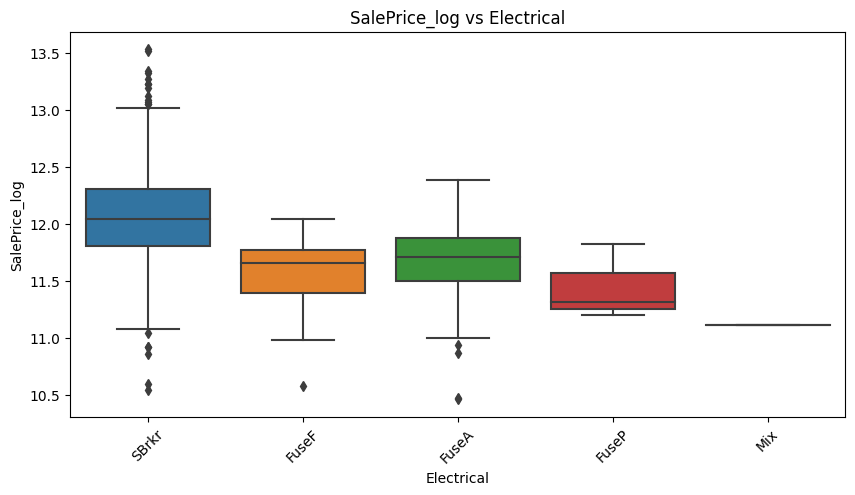

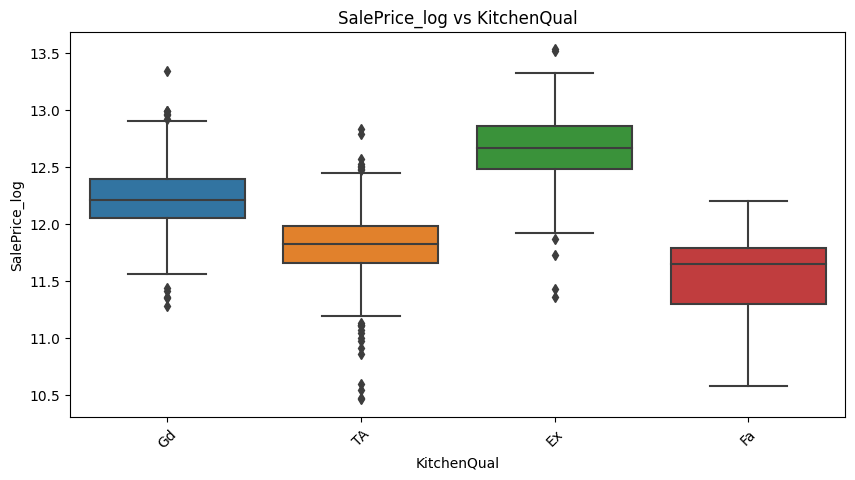

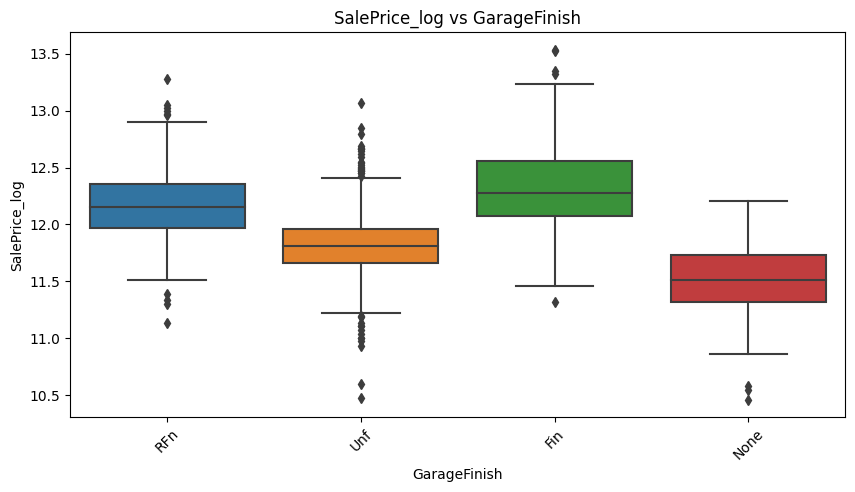

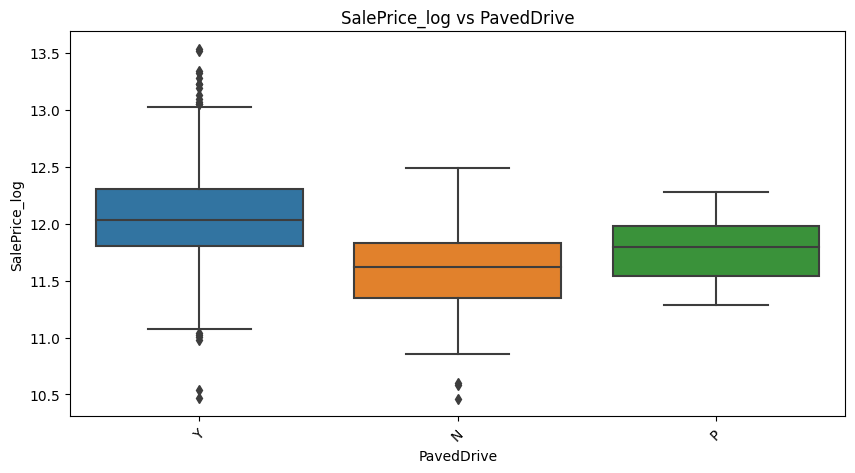

In [30]:
import seaborn as sns
import matplotlib.pyplot as plt

for col in categorical_cols:
    plt.figure(figsize=(10, 5))
    sns.boxplot(x=col, y="SalePrice_log", data=df)
    plt.title(f"SalePrice_log vs {col}")
    plt.xticks(rotation=45)
    plt.show()

In [31]:
df = pd.get_dummies(df, columns=one_hot_cols, drop_first=True)

In [32]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 73 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   OverallQual         1460 non-null   int64  
 1   YearBuilt           1460 non-null   int64  
 2   YearRemodAdd        1460 non-null   int64  
 3   TotalBsmtSF         1460 non-null   int64  
 4   1stFlrSF            1460 non-null   int64  
 5   GrLivArea           1460 non-null   int64  
 6   FullBath            1460 non-null   int64  
 7   TotRmsAbvGrd        1460 non-null   int64  
 8   GarageCars          1460 non-null   int64  
 9   GarageArea          1460 non-null   int64  
 10  SalePrice           1460 non-null   int64  
 11  SalePrice_log       1460 non-null   float64
 12  Street_Pave         1460 non-null   bool   
 13  CentralAir_Y        1460 non-null   bool   
 14  Utilities_NoSeWa    1460 non-null   bool   
 15  PavedDrive_P        1460 non-null   bool   
 16  PavedD

In [33]:
# Целевая переменная
target = "SalePrice_log"

X = df.drop(columns=[target, "SalePrice"])  # признаки
y = df[target]  # целевая переменная

In [34]:
from sklearn.ensemble import StackingRegressor, RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import RidgeCV
from sklearn.neighbors import KNeighborsRegressor
from sklearn.linear_model import LassoCV, ElasticNetCV
from sklearn.svm import SVR
from sklearn.model_selection import cross_val_score, KFold
from sklearn.metrics import make_scorer, mean_squared_error
import numpy as np

# --- Определяем базовые модели ---
base_models = [
    ('rf', RandomForestRegressor(n_estimators=200, max_depth=None, random_state=42)),
    ('gb', GradientBoostingRegressor(n_estimators=300, learning_rate=0.05, random_state=42)),
    ('knn', KNeighborsRegressor(n_neighbors=5)),
    ('svr', SVR(C=10, kernel='rbf')),
    ('lasso', LassoCV(cv=5)),
    ('elastic', ElasticNetCV(cv=5))
]

# --- Определяем мета-модель ---
meta_model = RidgeCV()

# --- Стек-модель ---
stacking_model = StackingRegressor(
    estimators=base_models,
    final_estimator=meta_model,
    cv=KFold(n_splits=5, shuffle=True, random_state=42)
)

# --- RMSE scorer ---
rmse_scorer = make_scorer(mean_squared_error, greater_is_better=False, squared=False)

# --- Оценка модели через k-fold ---
scores = cross_val_score(stacking_model, X, y,
                         cv=KFold(n_splits=5, shuffle=True, random_state=42),
                         scoring=rmse_scorer)

print("Средний RMSE:", -np.mean(scores))

Средний RMSE: 0.148909441002567


Обработка файла test.csv как я делал 

In [35]:
test = pd.read_csv("/kaggle/input/house-prices-advanced-regression-techniques/test.csv")

In [36]:
test.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition
0,1461,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,AllPub,...,120,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal
1,1462,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal
2,1463,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal
3,1464,60,RL,78.0,9978,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,6,2010,WD,Normal
4,1465,120,RL,43.0,5005,Pave,NaN,IR1,HLS,AllPub,...,144,0,NaN,NaN,NaN,0,1,2010,WD,Normal


In [37]:
test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1459 entries, 0 to 1458
Data columns (total 80 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1459 non-null   int64  
 1   MSSubClass     1459 non-null   int64  
 2   MSZoning       1455 non-null   object 
 3   LotFrontage    1232 non-null   float64
 4   LotArea        1459 non-null   int64  
 5   Street         1459 non-null   object 
 6   Alley          107 non-null    object 
 7   LotShape       1459 non-null   object 
 8   LandContour    1459 non-null   object 
 9   Utilities      1457 non-null   object 
 10  LotConfig      1459 non-null   object 
 11  LandSlope      1459 non-null   object 
 12  Neighborhood   1459 non-null   object 
 13  Condition1     1459 non-null   object 
 14  Condition2     1459 non-null   object 
 15  BldgType       1459 non-null   object 
 16  HouseStyle     1459 non-null   object 
 17  OverallQual    1459 non-null   int64  
 18  OverallC

In [38]:
missing = pd.DataFrame({
    "dtype": test.dtypes,
    "missing_count": test.isna().sum(),
    "missing_pct": test.isna().mean() * 100  # % пропусков
})

missing = missing[missing["missing_count"] > 0]
missing.sort_values(by="missing_count", ascending=False)

,dtype,missing_count,missing_pct
PoolQC,object,1456,99.794380
MiscFeature,object,1408,96.504455
Alley,object,1352,92.666210
Fence,object,1169,80.123372
MasVnrType,object,894,61.274846
FireplaceQu,object,730,50.034270
LotFrontage,float64,227,15.558602
GarageCond,object,78,5.346127
GarageYrBlt,float64,78,5.346127
GarageQual,object,78,5.346127


In [39]:
test = test.drop(columns=["PoolQC", "Alley", "MiscFeature", "Fence"])

In [40]:
cols_none = [
    "MasVnrType", "FireplaceQu", "GarageType", 
    "GarageFinish", "GarageQual", "GarageCond",
    "BsmtExposure", "BsmtQual", "BsmtCond", 
    "BsmtFinType1", "BsmtFinType2"
]

for col in cols_none:
    if col in test.columns:
        test[col] = test[col].fillna("None")

In [41]:
# Заполнение NaN
test["LotFrontage"] = test["LotFrontage"].fillna(test["LotFrontage"].median())

test["GarageYrBlt"] = test["GarageYrBlt"].fillna(test["GarageYrBlt"].median())

test.loc[test["MasVnrType"].isna(), "MasVnrType"] = "None"
test.loc[test["MasVnrType"] == "None", "MasVnrArea"] = 0
test["MasVnrArea"] = test["MasVnrArea"].fillna(test["MasVnrArea"].median())

test["MSZoning"] = test["MSZoning"].fillna(test["MSZoning"].mode()[0])

test["BsmtHalfBath"] = test["BsmtHalfBath"].fillna(0)
test["BsmtFullBath"] = test["BsmtFullBath"].fillna(0)
test["GarageArea"] = test["GarageArea"].fillna(0)
test["GarageCars"] = test["GarageCars"].fillna(0)
test["TotalBsmtSF"] = test["TotalBsmtSF"].fillna(0)
test["BsmtUnfSF"] = test["BsmtUnfSF"].fillna(0)
test["BsmtFinSF2"] = test["BsmtFinSF2"].fillna(0)
test["BsmtFinSF1"] = test["BsmtFinSF1"].fillna(0)

cat_fill_mode_cols = ["Utilities", "Functional", "KitchenQual", "Exterior2nd", "Exterior1st", "SaleType"]
for col in cat_fill_mode_cols:
    if col in test.columns:
        test[col] = test[col].fillna(test[col].mode()[0])

In [42]:
test.isna().sum()[test.isna().sum() > 0]

Series([], dtype: int64)

In [43]:
test.drop(columns=features_to_drop, inplace=True, errors="ignore")

In [44]:
print(f"Новое количество столбцов: {test.shape[1]}")

Новое количество столбцов: 49


In [45]:
print(f"Удалено признаков: {len(features_to_drop)}")

Удалено признаков: 27


In [46]:
categorical_cols = test.select_dtypes(include=["object"]).columns
for col in categorical_cols:
    print(col, test[col].nunique())

MSZoning 5
Street 2
LotShape 4
LandContour 4
Utilities 1
LotConfig 5
LandSlope 3
Neighborhood 25
Condition1 9
Condition2 5
BldgType 5
HouseStyle 7
RoofStyle 6
RoofMatl 4
Exterior1st 13
Exterior2nd 15
MasVnrType 4
ExterQual 4
ExterCond 5
Foundation 6
BsmtQual 5
BsmtCond 5
BsmtExposure 5
BsmtFinType1 7
BsmtFinType2 7
Heating 4
HeatingQC 5
CentralAir 2
Electrical 4
KitchenQual 4
Functional 7
FireplaceQu 6
GarageType 7
GarageFinish 4
GarageQual 5
GarageCond 6
PavedDrive 3
SaleType 9
SaleCondition 6


In [47]:
test.drop(columns=high_cardinality, inplace=True)

In [48]:
test = pd.get_dummies(test, columns=one_hot_cols, drop_first=True)

In [49]:
# Получаем множества имён колонок
cols_df = set(df.columns)
cols_test = set(test.columns)

# Колонки, которые есть в df, но нет в test
print("В df, но нет в test:", cols_df - cols_test)

# Колонки, которые есть в test, но нет в df
print("В test, но нет в df:", cols_test - cols_df)

# Проверка полного совпадения
print("Колонки совпадают?", cols_df == cols_test)

В df, но нет в test: {'Utilities_NoSeWa', 'SalePrice', 'Electrical_Mix', 'SalePrice_log'}
В test, но нет в df: set()
Колонки совпадают? False


In [50]:
# Находим отсутствующие колонки в test
missing_cols = set(X.columns) - set(test.columns)

# Добавляем их в test, заполняя нулями
for col in missing_cols:
    test[col] = 0

# Ставим колонки в том же порядке, что и в X
test = test[X.columns]

In [51]:
X_test = test  
stacking_model.fit(X,y)
predictions_log = stacking_model.predict(X_test)

# Переводим обратно из логарифма, если обучали на SalePrice_log
predictions = np.expm1(predictions_log)

In [52]:
import os
print(os.listdir("."))

['__notebook__.ipynb']


In [53]:
sample_submission = pd.read_csv("/kaggle/input/house-prices-advanced-regression-techniques/sample_submission.csv")

In [54]:
submission = pd.DataFrame({
    "Id": sample_submission["Id"],   # берём Id из sample_submission
    "SalePrice": predictions          # наши предсказания
})

submission.to_csv("submission.csv", index=False)
